# Bài giảng: Đại số Tuyến tính cho Khoa học Dữ liệu - Ngôn ngữ của Hình ảnh

Chào mừng các bạn đến với hành trình khám phá ngôn ngữ của dữ liệu! Hôm nay, chúng ta sẽ không chỉ học về các công thức toán học khô khan, mà sẽ cùng nhau "nhìn" thấy cách Đại số Tuyến tính trở thành công cụ nền tảng để máy tính có thể "hiểu" được thế giới thị giác. "Nhân vật chính" của chúng ta trong suốt hành trình này sẽ là các chữ số viết tay từ bộ dữ liệu MNIST nổi tiếng.

---

### **Chương 1: Nền tảng Véctơ và Không gian Véctơ**

*(Mở đầu hành trình khám phá ngôn ngữ của dữ liệu)*

#### **1.1. Véctơ là gì? - Từ Pixel đến một Điểm trong Không gian**

Về cơ bản, một véctơ là một danh sách các con số được sắp xếp theo một thứ tự nhất định. Nhưng để thực sự hiểu sức mạnh của nó, hãy nghĩ về véctơ như một **điểm** hoặc một **mũi tên** trong một không gian nào đó.

**Tầm nhìn: Hình ảnh là Véctơ!**

Hãy xem một chữ số "5" trong bộ MNIST. Nó là một hình ảnh đen trắng, kích thước 28x28 pixels. Đối với con người, đây là một hình ảnh. Đối với máy tính, đây là một ma trận 28x28 chứa các giá trị pixel (ví dụ: từ 0 là màu đen đến 255 là màu trắng).

Làm thế nào để biến nó thành một véctơ? Rất đơn giản: chúng ta "duỗi thẳng" nó ra. Ta lấy hàng thứ nhất, nối tiếp với hàng thứ hai, rồi hàng thứ ba, và cứ thế...

$$
\text{Ma trận 28x28} \rightarrow \text{Véctơ} \begin{pmatrix} \text{pixel}_{1,1} \\ \text{pixel}_{1,2} \\ \vdots \\ \text{pixel}_{28,28} \end{pmatrix}
$$

Kết quả là chúng ta có một véctơ duy nhất với $28 \times 28 = 784$ phần tử. Mỗi chữ số viết tay giờ đây là một điểm duy nhất trong một **không gian 784 chiều**!


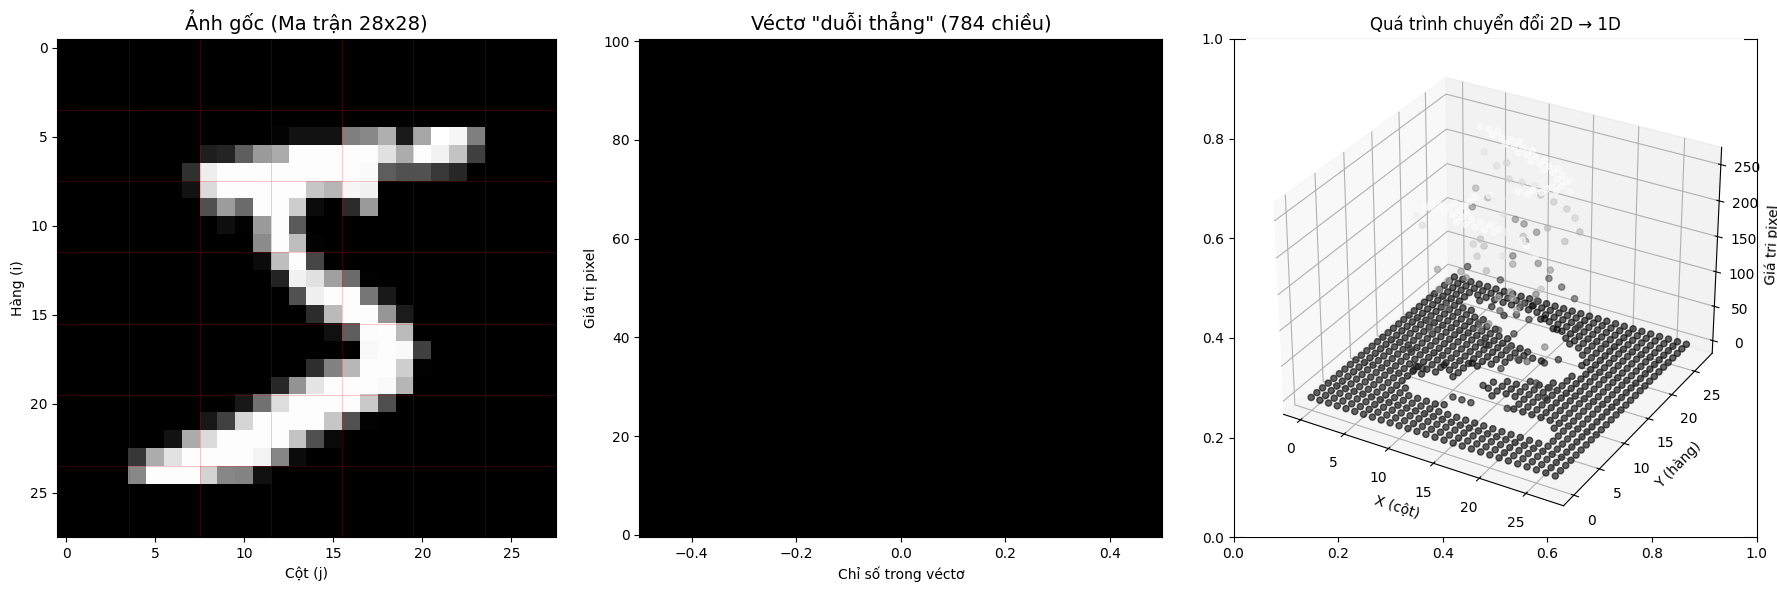

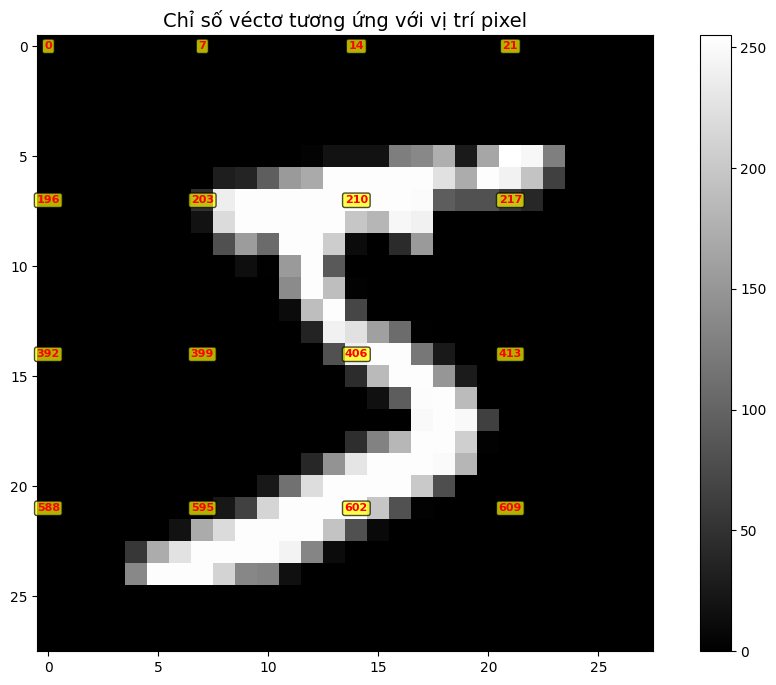

In [2]:
# Visualization Code for Flattening an Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X, y = mnist.data, mnist.target

# Select a specific digit (e.g., '5')
digit_5_indices = np.where(y == '5')[0]
sample_image = X[digit_5_indices[0]].reshape(28, 28)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original 28x28 image
axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title('Ảnh gốc (Ma trận 28x28)', fontsize=14)
axes[0].set_xlabel('Cột (j)')
axes[0].set_ylabel('Hàng (i)')

# Add grid to show pixel structure
for i in range(0, 28, 4):
    axes[0].axhline(i-0.5, color='red', alpha=0.3, linewidth=0.5)
    axes[0].axvline(i-0.5, color='red', alpha=0.3, linewidth=0.5)

# Flattened vector visualization
flattened = sample_image.flatten()
axes[1].imshow(flattened.reshape(-1, 1), cmap='gray', aspect='auto')
axes[1].set_title('Véctơ "duỗi thẳng" (784 chiều)', fontsize=14)
axes[1].set_xlabel('Chỉ số trong véctơ')
axes[1].set_ylabel('Giá trị pixel')

# Show first few elements
axes[1].set_xlim(-0.5, 0.5)
axes[1].set_ylim(-0.5, 100.5)

# 3D visualization of the flattening process
ax3d = fig.add_subplot(133, projection='3d')

# Create a 3D surface showing the flattening transformation
x_pos = np.arange(28)
y_pos = np.arange(28)
X_pos, Y_pos = np.meshgrid(x_pos, y_pos)

# Show how 2D coordinates map to 1D
colors = plt.cm.viridis(sample_image / np.max(sample_image))
ax3d.scatter(X_pos.flatten(), Y_pos.flatten(), flattened, 
            c=flattened, cmap='gray', alpha=0.6)

ax3d.set_xlabel('X (cột)')
ax3d.set_ylabel('Y (hàng)')
ax3d.set_zlabel('Giá trị pixel')
ax3d.set_title('Quá trình chuyển đổi 2D → 1D', fontsize=12)

plt.tight_layout()
plt.show()

# Show the mapping from 2D to 1D indices
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(sample_image, cmap='gray')

# Add text annotations showing flattened indices
for i in range(0, 28, 7):
    for j in range(0, 28, 7):
        flat_index = i * 28 + j
        ax.text(j, i, f'{flat_index}', color='red', fontsize=8, 
                ha='center', va='center', weight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

ax.set_title('Chỉ số véctơ tương ứng với vị trí pixel', fontsize=14)
plt.colorbar(im)
plt.show()


#### **1.2. Không gian Véctơ và Không gian Con**

**Không gian véctơ** là "sân chơi" chứa tất cả các véctơ có thể có. Ví dụ, không gian $\mathbb{R}^{784}$ là tập hợp tất cả các hình ảnh 28x28 có thể tồn tại, kể cả những hình ảnh chỉ là nhiễu ngẫu nhiên.

Một **không gian con** là một "sân chơi nhỏ" bên trong sân chơi lớn, nhưng nó vẫn tuân thủ các quy tắc (ví dụ: cộng hai véctơ trong không gian con vẫn cho ra một véctơ trong không gian con đó).

**Câu chuyện:** Hãy tưởng tượng toàn bộ không gian $\mathbb{R}^{784}$ là vô số các hình ảnh.
*   Một không gian con có thể là tập hợp *tất cả các hình ảnh chỉ chứa một đường thẳng đứng*. Nếu bạn cộng hai hình ảnh có đường thẳng đứng, bạn vẫn sẽ có một hình ảnh có đường thẳng đứng.
*   Một không gian con khác có thể là tập hợp *tất cả các hình ảnh của chữ số '0'*. Nếu bạn lấy trung bình cộng của nhiều hình ảnh chữ số '0', kết quả vẫn sẽ là một hình ảnh trông giống chữ số '0'.

#### **1.3. Tổ hợp Tuyến tính và Sự Độc lập Tuyến tính**

Một **tổ hợp tuyến tính** là việc "pha trộn" các véctơ cơ bản để tạo ra một véctơ mới.
$$
v_{mới} = c_1 v_1 + c_2 v_2 + \dots + c_n v_n
$$

*   **Phụ thuộc tuyến tính:** Khi một véctơ có thể được tạo ra từ những véctơ khác.
*   **Độc lập tuyến tính:** Khi các véctơ là "độc nhất", không véctơ nào có thể được biểu diễn bằng tổ hợp của các véctơ còn lại.

**Tầm nhìn:** Một chữ số '8' có thể được xem là tổ hợp tuyến tính của một chữ số '0' (vòng tròn trên) và một chữ số '0' khác (vòng tròn dưới). Một chữ số '3' bị viết nghiêng có thể được coi là tổ hợp của một chữ số '3' chuẩn và một "véctơ nghiêng". Sự độc lập tuyến tính giúp chúng ta tìm ra những "nét vẽ cơ bản" nhất không thể rút gọn được nữa.

#### **1.4. Cơ sở và Chiều**

*   **Cơ sở (Basis):** Là một tập hợp các véctơ **độc lập tuyến tính** tối thiểu có thể "xây dựng" nên toàn bộ không gian. Chúng là những "viên gạch Lego" cơ bản nhất.
*   **Chiều (Dimension):** Là số lượng véctơ trong một bộ cơ sở.

**Tầm nhìn:** Thay vì lưu trữ hàng ngàn biến thể của chữ số '0', chúng ta có thể chỉ cần tìm một "cơ sở" gồm một vài hình ảnh "0" tiêu biểu (ví dụ: '0' tròn, '0' méo, '0' cao). Mọi chữ số '0' khác có thể được xấp xỉ bằng một tổ hợp tuyến tính của các véctơ cơ sở này. Đây là ý tưởng cốt lõi đằng sau các thuật toán nén ảnh và giảm chiều dữ liệu như PCA (Phân tích thành phần chính).

---

### **Chương 2: Ma trận và Phép toán Ma trận**

*(Biến đổi dữ liệu qua lăng kính ma trận)*

#### **2.1. Ma trận: Ngôn ngữ của Biến đổi**

Nếu véctơ là một điểm, thì **ma trận là một hành động** – một phép biến đổi làm di chuyển điểm đó. Ma trận là "bộ điều khiển" cho các phép biến đổi hình học.

*   **Ma trận đơn vị (I):** Ma trận "không làm gì cả". $Iv = v$.
*   **Ma trận đường chéo:** Gây ra phép co giãn (scaling) dọc các trục.
*   **Ma trận hoán vị:** Tráo đổi các trục tọa độ (ví dụ: lật hình ảnh).

#### **2.2. Phép nhân Ma trận: Sự kết hợp của các Biến đổi**

Phép nhân ma trận $A \cdot B$ không chỉ là một công thức. Về mặt hình học, nó có nghĩa là: **thực hiện phép biến đổi B, *sau đó* thực hiện phép biến đổi A**.

$$
(A \cdot B) v = A (B v)
$$

Đây là lý do tại sao thứ tự lại cực kỳ quan trọng: **$AB \neq BA$**!
"Xoay rồi cắt xiên" một hình ảnh sẽ cho kết quả khác hoàn toàn với "Cắt xiên rồi xoay".

**Matplotlib Demo: AB ≠ BA trên chữ số MNIST**


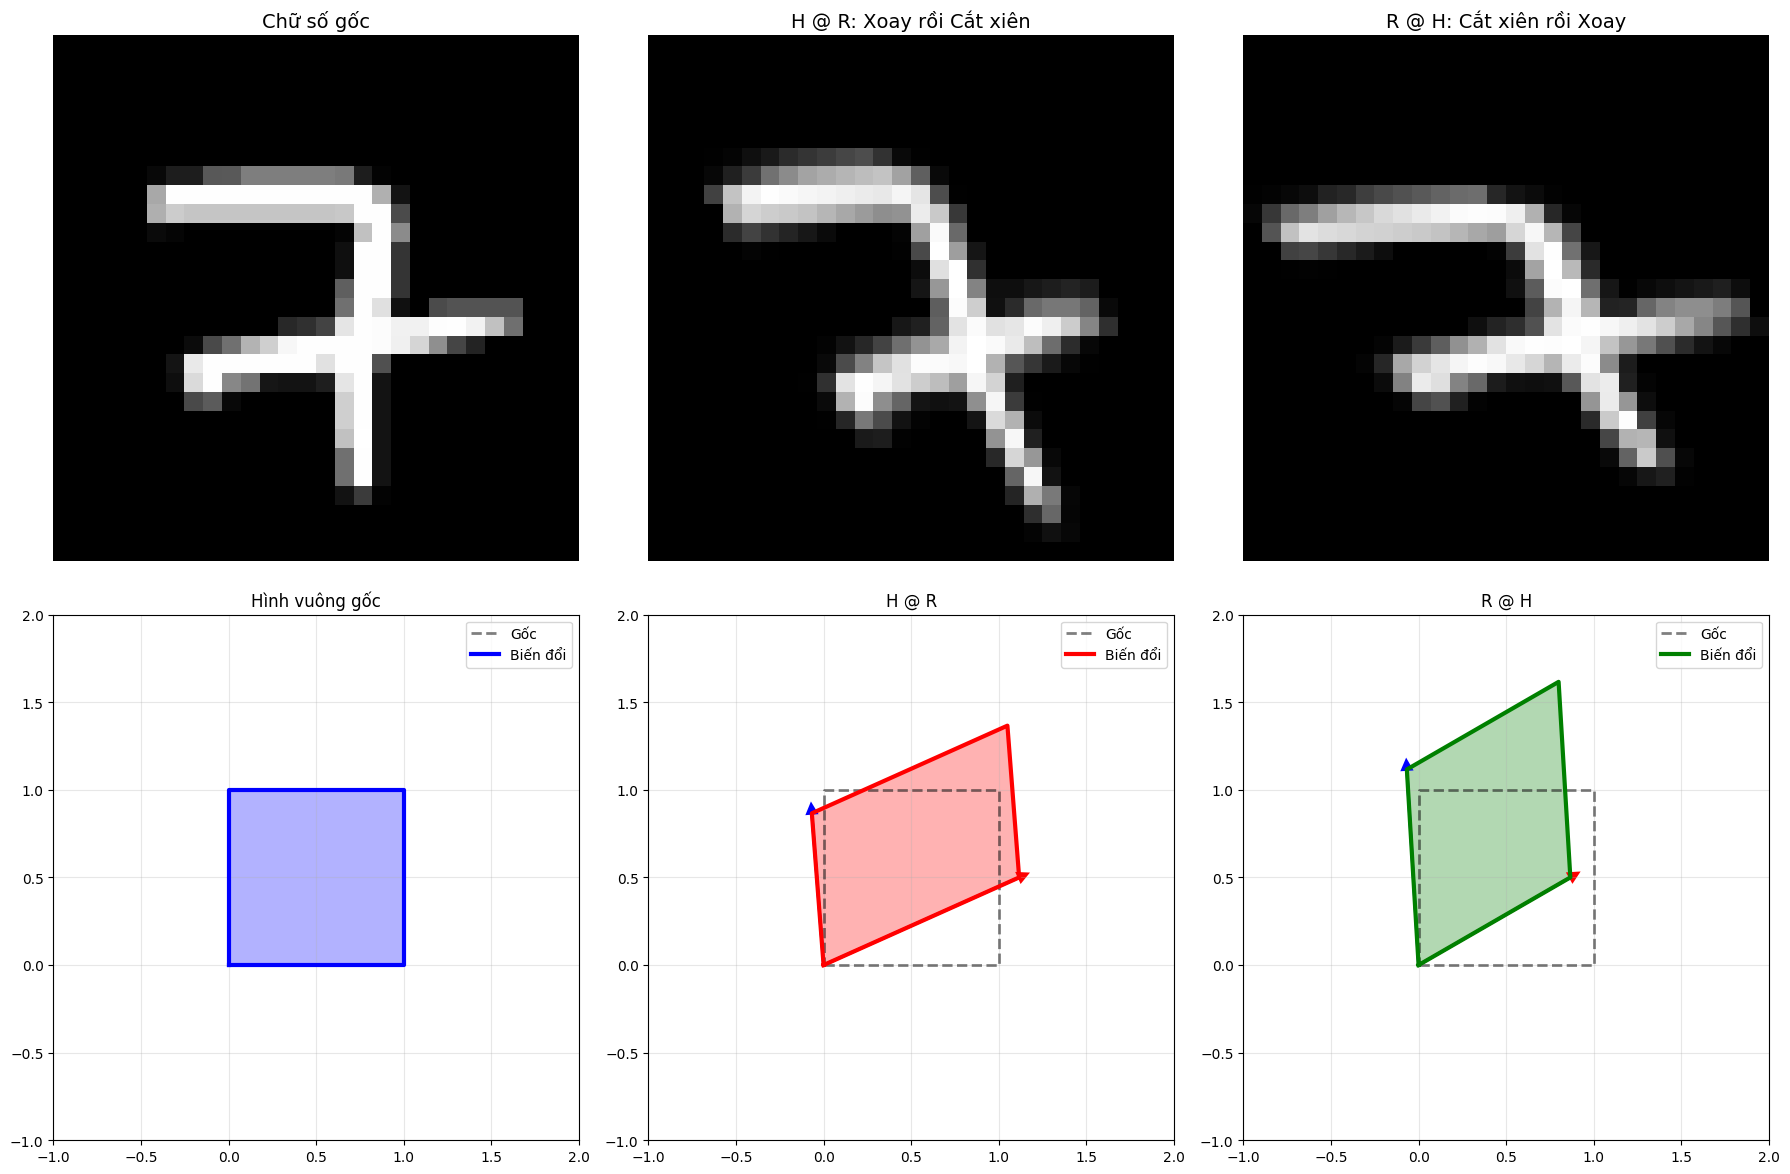

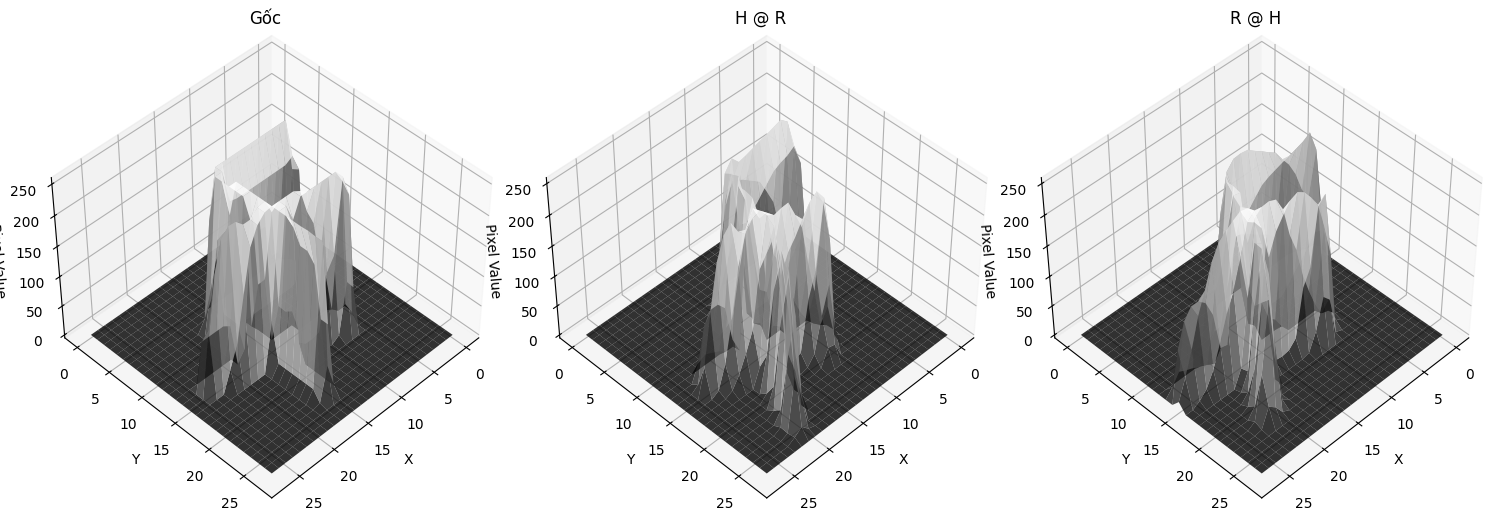

Ma trận Xoay (R):
[[ 0.8660254 -0.5      ]
 [ 0.5        0.8660254]]

Ma trận Cắt xiên (H):
[[1.  0.5]
 [0.  1. ]]

H @ R (Xoay rồi Cắt xiên):
[[ 1.1160254 -0.0669873]
 [ 0.5        0.8660254]]

R @ H (Cắt xiên rồi Xoay):
[[ 0.8660254 -0.0669873]
 [ 0.5        1.1160254]]

Khác biệt giữa H@R và R@H:
[[ 0.25  0.  ]
 [ 0.   -0.25]]


In [3]:
# Visualization Code for AB != BA
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
import warnings
warnings.filterwarnings('ignore')

# Get a sample MNIST digit (digit '7')
digit_7_indices = np.where(y == '7')[0]
sample_digit = X[digit_7_indices[2]].reshape(28, 28)

# Define transformation matrices
# Rotation matrix (30 degrees)
theta = np.pi / 6  # 30 degrees
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]])

# Shear matrix (horizontal shear)
H = np.array([[1, 0.5],
              [0, 1]])

# Create combined transformations
M1 = H @ R  # Rotate then Shear
M2 = R @ H  # Shear then Rotate

def apply_2d_transform(image, transform_matrix):
    """Apply 2D transformation to image"""
    # Convert to homogeneous coordinates for transformation
    center = np.array(image.shape) / 2
    offset_matrix = np.array([[1, 0, center[0]], 
                              [0, 1, center[1]], 
                              [0, 0, 1]])
    
    # Create 3x3 transformation matrix
    transform_3x3 = np.eye(3)
    transform_3x3[:2, :2] = transform_matrix
    
    # Apply transformation with center offset
    full_transform = np.linalg.inv(offset_matrix) @ transform_3x3 @ offset_matrix
    
    # Apply transformation
    transformed = affine_transform(image, np.linalg.inv(full_transform[:2, :2]), 
                                  offset=full_transform[:2, 2], order=1, 
                                  output_shape=image.shape, mode='constant')
    return transformed

# Apply transformations
digit_M1 = apply_2d_transform(sample_digit, M1)
digit_M2 = apply_2d_transform(sample_digit, M2)

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top row: 2D visualization
axes[0, 0].imshow(sample_digit, cmap='gray')
axes[0, 0].set_title('Chữ số gốc', fontsize=14)
axes[0, 0].axis('off')

axes[0, 1].imshow(digit_M1, cmap='gray')
axes[0, 1].set_title('H @ R: Xoay rồi Cắt xiên', fontsize=14)
axes[0, 1].axis('off')

axes[0, 2].imshow(digit_M2, cmap='gray')
axes[0, 2].set_title('R @ H: Cắt xiên rồi Xoay', fontsize=14)
axes[0, 2].axis('off')

# Bottom row: Show transformation effect on unit square
unit_square = np.array([[0, 1, 1, 0, 0],
                        [0, 0, 1, 1, 0]])

for i, (matrix, title) in enumerate([(np.eye(2), 'Hình vuông gốc'),
                                     (M1, 'H @ R'),
                                     (M2, 'R @ H')]):
    ax = axes[1, i]
    
    # Transform unit square
    transformed_square = matrix @ unit_square
    
    # Plot original square
    ax.plot(unit_square[0], unit_square[1], 'k--', linewidth=2, alpha=0.5, label='Gốc')
    
    # Plot transformed square
    colors = ['blue', 'red', 'green'][i]
    ax.plot(transformed_square[0], transformed_square[1], color=colors, 
            linewidth=3, label='Biến đổi')
    ax.fill(transformed_square[0], transformed_square[1], alpha=0.3, color=colors)
    
    # Plot basis vectors
    if i > 0:
        i_hat = matrix @ np.array([1, 0])
        j_hat = matrix @ np.array([0, 1])
        ax.arrow(0, 0, i_hat[0], i_hat[1], head_width=0.05, 
                head_length=0.05, fc='red', ec='red', linewidth=2)
        ax.arrow(0, 0, j_hat[0], j_hat[1], head_width=0.05, 
                head_length=0.05, fc='blue', ec='blue', linewidth=2)
    
    ax.set_xlim(-1, 2)
    ax.set_ylim(-1, 2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

# 3D visualization showing the transformation effect
fig = plt.figure(figsize=(15, 5))

for i, (data, title) in enumerate([(sample_digit, 'Gốc'),
                                   (digit_M1, 'H @ R'),
                                   (digit_M2, 'R @ H')]):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    # Create coordinate grids
    x = np.arange(28)
    y = np.arange(28)
    X, Y = np.meshgrid(x, y)
    
    # Plot 3D surface
    surf = ax.plot_surface(X, Y, data, cmap='gray', alpha=0.8)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Pixel Value')
    ax.set_title(title, fontsize=12)
    ax.view_init(elev=45, azim=45)

plt.tight_layout()
plt.show()

# Show matrix values
print("Ma trận Xoay (R):")
print(R)
print("\nMa trận Cắt xiên (H):")
print(H)
print("\nH @ R (Xoay rồi Cắt xiên):")
print(M1)
print("\nR @ H (Cắt xiên rồi Xoay):")
print(M2)
print("\nKhác biệt giữa H@R và R@H:")
print(M1 - M2)


#### **2.3. Ma trận Chuyển vị ($A^T$)**

Chuyển vị là hành động "lật" ma trận qua đường chéo chính, biến hàng thành cột. Nó giống như việc "thay đổi góc nhìn" của dữ liệu.

#### **2.4. Ma trận Nghịch đảo ($A^{-1}$): Phép toán "Hoàn tác"**

Nếu ma trận $A$ thực hiện một phép biến đổi (ví dụ: quay 45 độ), thì ma trận nghịch đảo $A^{-1}$ sẽ **hoàn tác** lại phép biến đổi đó (quay ngược lại 45 độ).

$$
A^{-1} (A v) = v
$$

**Tầm nhìn: Khôi phục Hình ảnh**
Nếu một chữ số MNIST bị làm méo bởi một ma trận $A$, chúng ta có thể dùng $A^{-1}$ để khôi phục lại hình ảnh gốc. Điều này chỉ khả thi khi ma trận $A$ là "khả nghịch" (tức là nó không làm mất thông tin, ví dụ như phép chiếu làm bẹp không gian từ 3D xuống 2D là không thể hoàn tác).



```python
# Visualization Code for Matrix Inverse
# 1. Start with an original MNIST digit image `x`.
# 2. Define an invertible transformation matrix `A` (e.g., a combination of rotation and non-zero scaling).
# 3. Apply the transformation to get the distorted image `b = Ax`.
# 4. Calculate the inverse matrix `A_inv = np.linalg.inv(A)`.
# 5. Apply the inverse transformation to `b` to get the restored image `x_restored = A_inv * b`.
# 6. Display three images side-by-side: "Ảnh gốc", "Ảnh bị biến đổi bởi A", and "Ảnh khôi phục bởi A^-1".
# 7. The first and third images should look nearly identical.
```


### **Chương 3: Khám phá Không gian dữ liệu: Các Biến đổi Nâng cao và Cấu trúc ẩn**

*(Đi sâu vào thế giới dữ liệu ảnh)*

#### **3.1. Tấm bản đồ dữ liệu: Bốn Không gian Cơ bản**

Mọi ma trận $A$ đều định nghĩa bốn không gian con cơ bản, hé lộ cách nó xử lý thông tin:
1.  **Không gian Cột `C(A)`:** Không gian "đầu ra". Tập hợp tất cả các véctơ có thể được tạo ra bởi phép biến đổi $A$.
2.  **Không gian Hạt nhân `N(A)`:** Không gian "thông tin bị mất". Tập hợp tất cả các véctơ bị biến thành véctơ không sau khi qua phép biến đổi $A$.
3.  **Không gian Hàng `C(A^T)`:** Không gian "đầu vào" thực sự quan trọng.
4.  **Không gian Hạt nhân Trái `N(A^T)`**.

**Định lý Hạng-Hạt nhân (Rank-Nullity Theorem):**
$$ \text{rank}(A) + \text{nullity}(A) = n $$
Trong đó `rank(A)` là chiều của không gian cột, `nullity(A)` là chiều của không gian hạt nhân, và `n` là số cột của $A$ (chiều của không gian đầu vào).

**Tầm nhìn:**
*   `C(A)`: Những đặc trưng "hữu ích" nào của chữ số được giữ lại sau khi biến đổi.
*   `N(A)`: Những "nhiễu" hoặc chi tiết nào của chữ số bị loại bỏ hoàn toàn.
Định lý này nói rằng tổng số "hướng thông tin" ban đầu luôn được bảo toàn, hoặc là nó được biến đổi (rank) hoặc là nó bị triệt tiêu (nullity).

#### **3.2. Chuyển đổi Góc nhìn: Đổi cơ sở và Trực giao hóa**

**Thay đổi Cơ sở (Change of Basis):**
Một véctơ không thay đổi, nhưng "tọa độ" của nó phụ thuộc vào "hệ quy chiếu" (cơ sở) mà bạn chọn. Thay đổi cơ sở giống như việc bạn đeo một cặp kính mới để nhìn thế giới.

**Tầm nhìn:** Cơ sở tiêu chuẩn (các pixel) có thể không phải là cách tốt nhất để mô tả một chữ số. Sẽ tốt hơn nếu chúng ta có một cơ sở gồm các véctơ đại diện cho "nét dọc", "nét ngang", "nét cong trái", "nét cong phải". Trong hệ cơ sở mới này, tọa độ của chữ số "0" sẽ có giá trị lớn ở các véctơ "nét cong" và giá trị nhỏ ở các véctơ "nét thẳng". Điều này giúp máy học nhận ra bản chất của chữ số dễ dàng hơn.

**Trực giao hóa Gram-Schmidt:**
Đây là thuật toán để "làm sạch" một bộ cơ sở, biến các véctơ xiên góc thành một bộ véctơ vuông góc hoàn hảo (trực giao). Các đặc trưng trực giao thì không bị trùng lặp thông tin, giúp các mô hình học máy hoạt động hiệu quả hơn.

#### **3.3. Ánh xạ Tuyến tính: Đằng sau các Ma trận**

Mỗi phép biến đổi tuyến tính (một hàm tuân thủ các quy tắc cộng và nhân vô hướng) đều có thể được biểu diễn bằng một ma trận.

**Tầm nhìn:** Khi một mạng nơ-ron học cách nhận dạng chữ số, thực chất nó đang tìm kiếm các ma trận tối ưu. Mỗi lớp "fully-connected" trong mạng nơ-ron chính là một phép nhân ma trận (biến đổi tuyến tính) theo sau bởi một hàm phi tuyến. Mạng nơ-ron đang học cách "nhào nặn" không gian 784 chiều sao cho các điểm dữ liệu của cùng một chữ số (ví dụ: tất cả các số '5') sẽ tụ lại gần nhau và tách xa khỏi các cụm chữ số khác.

#### **3.4. Ứng dụng quan trọng: Giải bài toán Bình phương bé nhất (Least Squares)**

Khi hệ phương trình $Ax = b$ không có nghiệm chính xác (do dữ liệu bị nhiễu), chúng ta không tìm nghiệm hoàn hảo nữa. Thay vào đó, chúng ta tìm nghiệm xấp xỉ $\hat{x}$ sao cho sai số $||A\hat{x} - b||^2$ là nhỏ nhất có thể.

Lời giải được tìm thấy qua **phương trình chuẩn (Normal Equation)**:
$$
A^T A \hat{x} = A^T b
$$
**Tầm nhìn:** Hãy tưởng tượng bạn có các điểm pixel nhiễu tạo thành một đường cong của chữ số '2'. Bạn muốn "khớp" một đường cong parabol hoàn hảo vào các điểm này. Sẽ không có parabol nào đi qua tất cả các điểm nhiễu. Bài toán bình phương bé nhất sẽ tìm ra parabol "tốt nhất" - parabol nằm gần tất cả các điểm nhất. Đây là một công cụ cực kỳ mạnh mẽ để rút ra tín hiệu hữu ích từ dữ liệu nhiễu trong thế giới thực.



```python
# Visualization Code for Least Squares
# 1. Extract some pixel coordinates (x, y) from the edge of an MNIST digit. Add some random noise to these coordinates.
# 2. We want to fit a quadratic curve (y = ax^2 + bx + c) to these noisy points.
# 3. This sets up an overdetermined system Ax = b, where:
#    - A has columns [x^2, x, 1]
#    - x is the vector of unknown coefficients [a, b, c]
#    - b is the vector of noisy y-coordinates
# 4. Solve for the best-fit coefficients `x_hat` using the normal equation: `x_hat = inv(A.T @ A) @ A.T @ b`.
# 5. Plot the noisy data points as a scatter plot.
# 6. Plot the fitted curve using the calculated coefficients `x_hat`.
# 7. The plot will show a smooth curve that doesn't hit every point but provides the best overall approximation.
```